# Генератор пользовательских данных для детектирования клеток крови — HT_5

1.	Преобразуйте генератор данных для решения задачи детектирования объекта (таргет сформирован в виде x,y,w,h).
2.	Выберите модель YOLO из представленных. Натренируйте модель для решения задачи детектирования клеток Model Training with Ultralytics YOLO - Ultralytics YOLO Docs. bing.com/ck/a?!&&p=b3441c4eae8ebdb939a51092e90a86948b3b4c219a460d43461448e588b9e8a0JmltdHM9MTc3NzA3NTIwMA&ptn=3&ver=2&hsh=4&fclid=12094f40-6510-69b3-1238-5a946447681d&psq=yolo+detection+training&u=a1aHR0cHM6Ly9kb2NzLnVsdHJhbHl0aWNzLmNvbS90YXNrcy9kZXRlY3Qv&ntb=1
3.	Решите хадачу подсчета количества клеток. Количество найденных клеток является корректным, если относительная погрешность вычислений меньше 10%.


In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import os
import random
from typing import Tuple, List
from torch.utils.data import Dataset
from torch.utils.data import random_split
import torch
from torchvision import transforms
from tqdm import tqdm
from ultralytics import YOLO

## 1. Загрузка и подготовка данных

In [20]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

MAX_CELLS = 9
BATCH_SIZE = 16
EPOCHS = 50
LR = 0.001

TOTAL_DATA = 1000
TRAIN_RATIO = 0.8
VAL_RATIO = 0.2

TRAIN_SIZE = int(TOTAL_DATA * TRAIN_RATIO)
VAL_SIZE = int(TOTAL_DATA * VAL_RATIO)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

DATA_DIR = 'BCCD Dataset with mask/train'
IMAGES_DIR = os.path.join(DATA_DIR, 'original')
MASKS_DIR = os.path.join(DATA_DIR, 'mask')

BACKGROUND_PATCHES_DIR = 'background_patches'
CELL_PATCHES_DIR = 'cell_patches'
os.makedirs(BACKGROUND_PATCHES_DIR, exist_ok=True)
os.makedirs(CELL_PATCHES_DIR, exist_ok=True)

YOLO_DATASET_DIR = "yolo_cell_dataset"
for split in ['train', 'val']:
    os.makedirs(os.path.join(YOLO_DATASET_DIR, split, 'images'), exist_ok=True)
    os.makedirs(os.path.join(YOLO_DATASET_DIR, split, 'labels'), exist_ok=True)

Device: cuda


In [21]:
def load_blood_cell_dataset(images_dir, masks_dir, max_images=1000):
    images = []
    masks = []
    
    for filename in os.listdir(images_dir):
        if len(images) >= max_images:
            break
            
        img_path = os.path.join(images_dir, filename)
        mask_path = os.path.join(masks_dir, filename)
        
        if os.path.exists(mask_path):
            img = cv2.imread(img_path)
            mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
            
            if img is not None and mask is not None:
                images.append(img)
                masks.append(mask)
    
    return images, masks

In [22]:
def extract_patches(images, masks, patch_size=(128, 128), n_patches=100):
    background_patches = []
    cell_patches = []
    
    for img, mask in zip(images, masks):
        h, w = img.shape[:2]
        
        for _ in range(n_patches // 2):
            x = random.randint(0, w - patch_size[1])
            y = random.randint(0, h - patch_size[0])
            
            patch = img[y:y+patch_size[0], x:x+patch_size[1]]
            mask_patch = mask[y:y+patch_size[0], x:x+patch_size[1]]
            
            if np.count_nonzero(mask_patch) < patch_size[0] * patch_size[1] * 0.05:
                background_patches.append(patch)
        
        contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        for contour in contours:
            x, y, w_cell, h_cell = cv2.boundingRect(contour)
            
            if w_cell > 20 and h_cell > 20:
                pad = 10
                x1 = max(0, x - pad)
                y1 = max(0, y - pad)
                x2 = min(img.shape[1], x + w_cell + pad)
                y2 = min(img.shape[0], y + h_cell + pad)
                
                cell_patch = img[y1:y2, x1:x2]
                cell_mask = mask[y1:y2, x1:x2]
                
                cell_only = cv2.bitwise_and(cell_patch, cell_patch, mask=cell_mask)
                if cell_only.size > 0:
                    cell_patches.append(cell_only)
    
    return background_patches, cell_patches

In [23]:
def save_patches(background_patches, cell_patches, bg_dir, cell_dir, max_save=50):
    for i, patch in enumerate(background_patches[:max_save]):
        cv2.imwrite(os.path.join(bg_dir, f'bg_{i}.png'), patch)
    
    for i, patch in enumerate(cell_patches[:max_save]):
        cv2.imwrite(os.path.join(cell_dir, f'cell_{i}.png'), patch)
    
    print(f"Сохранено {len(background_patches)} патчей фона и {len(cell_patches)} патчей клеток")

In [24]:
try:
    images, masks = load_blood_cell_dataset(IMAGES_DIR, MASKS_DIR, 200)
    print(f"Загружено {len(images)} изображений")
    
    bg_patches, cell_patches = extract_patches(images, masks)
    save_patches(bg_patches, cell_patches, BACKGROUND_PATCHES_DIR, CELL_PATCHES_DIR)
    
except FileNotFoundError:
    print("Набор данных не найден. Используем синтетические данные.")
    bg_patches, cell_patches = [], []

Загружено 200 изображений
Сохранено 2265 патчей фона и 14454 патчей клеток


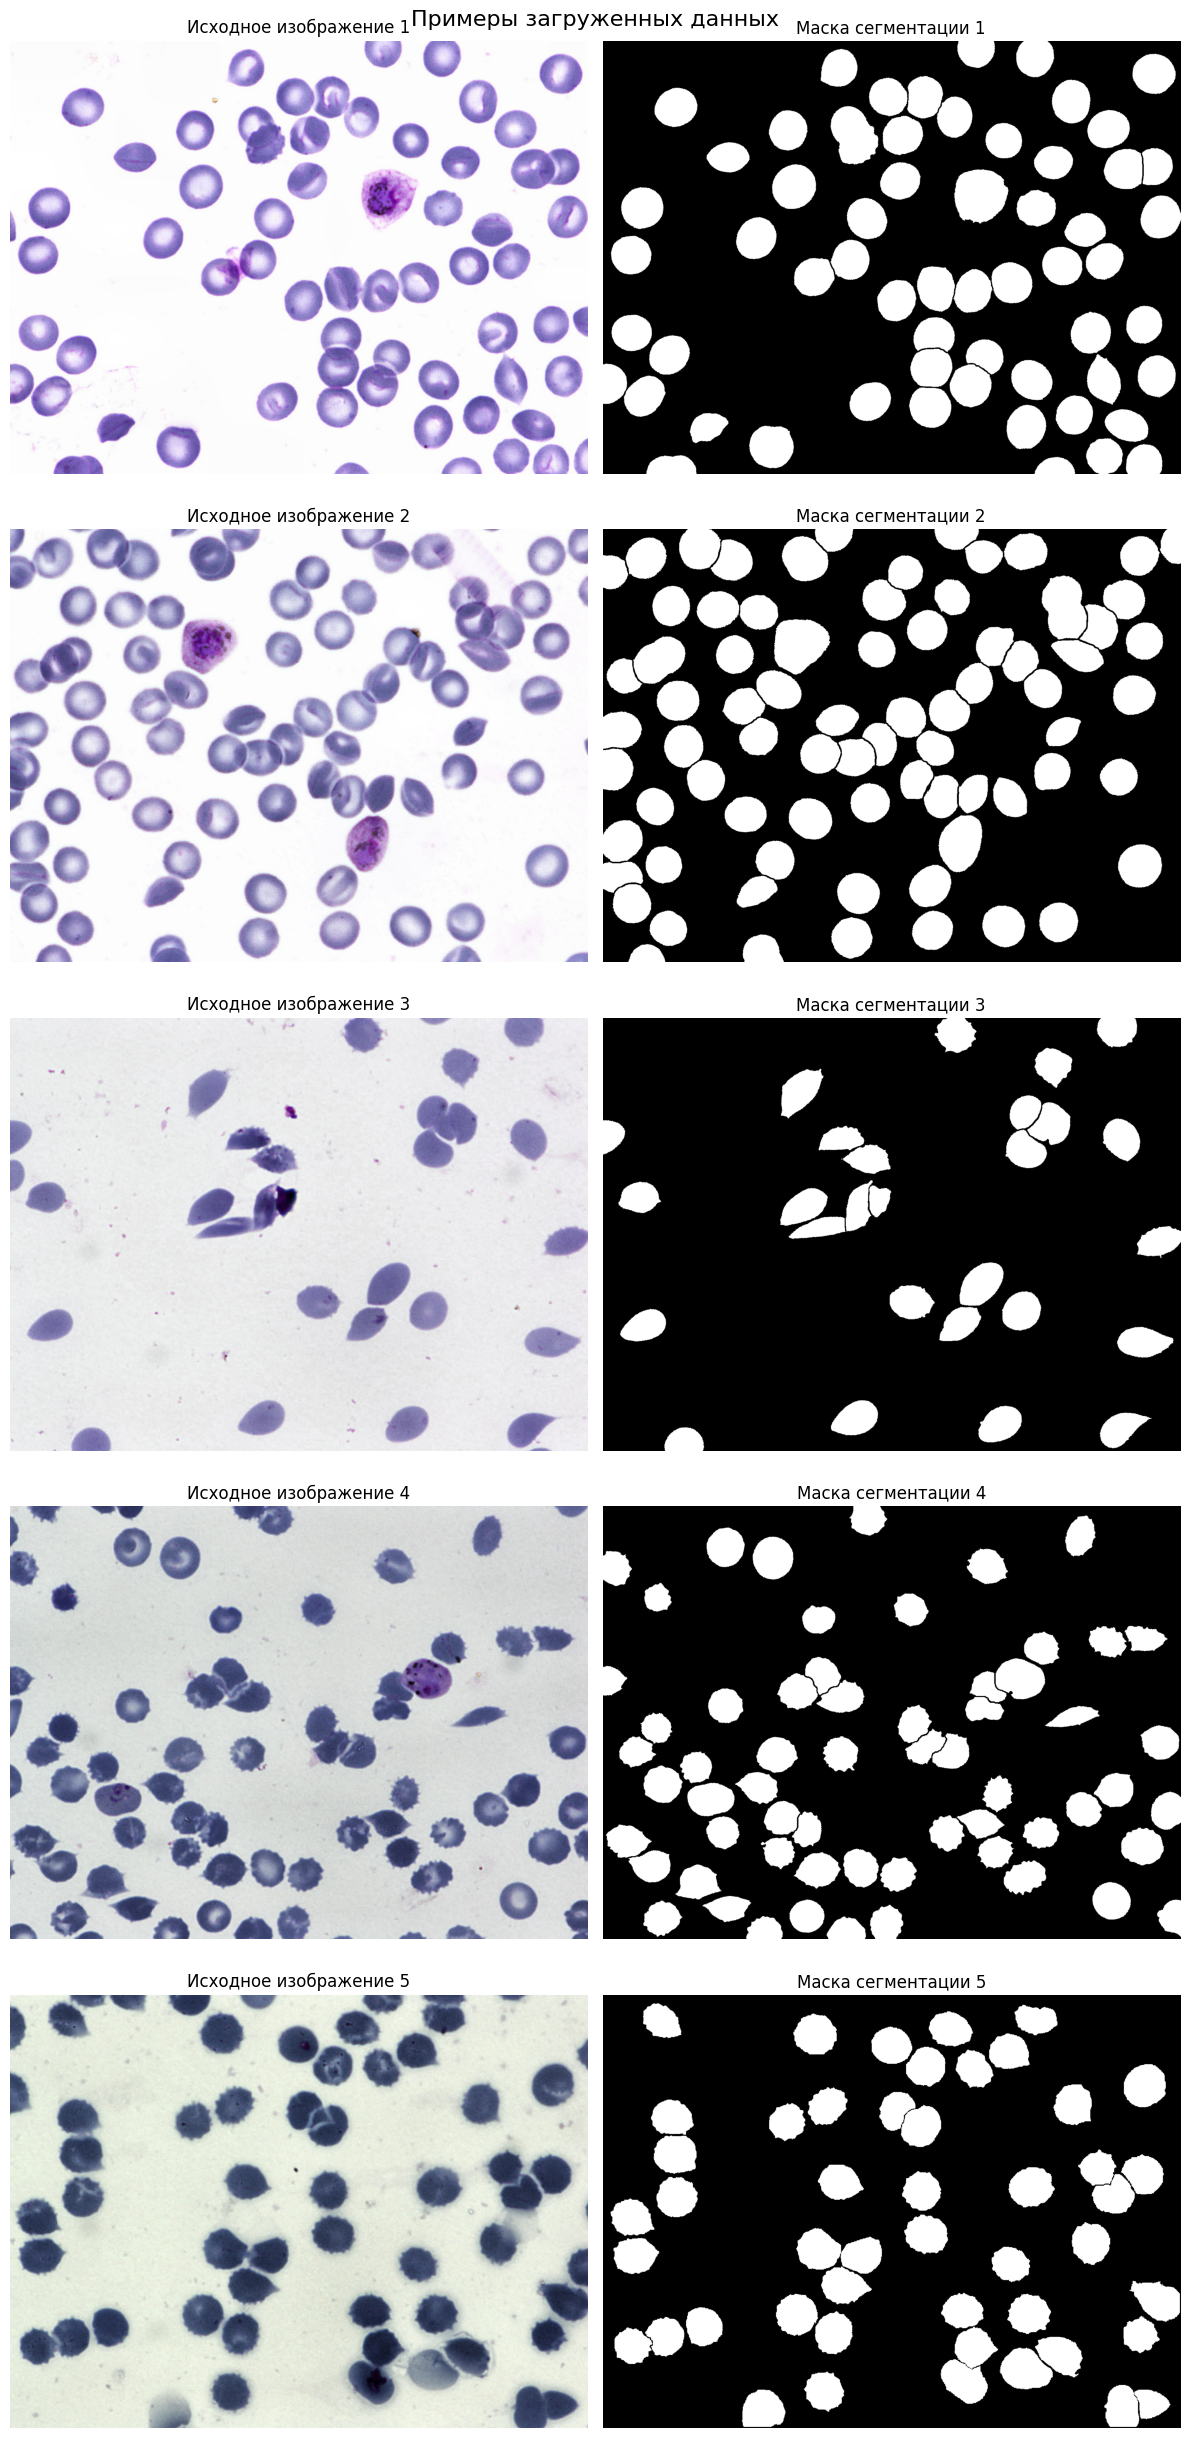

In [25]:
fig, axes = plt.subplots(5, 2, figsize=(12, 25))
fig.suptitle("Примеры загруженных данных", fontsize=16)

for i in range(5):
    axes[i, 0].imshow(cv2.cvtColor(images[i], cv2.COLOR_BGR2RGB))
    axes[i, 0].set_title(f"Исходное изображение {i+1}")
    axes[i, 0].axis('off')
    
    axes[i, 1].imshow(masks[i], cmap='gray')
    axes[i, 1].set_title(f"Маска сегментации {i+1}")
    axes[i, 1].axis('off')

plt.tight_layout()
plt.show()

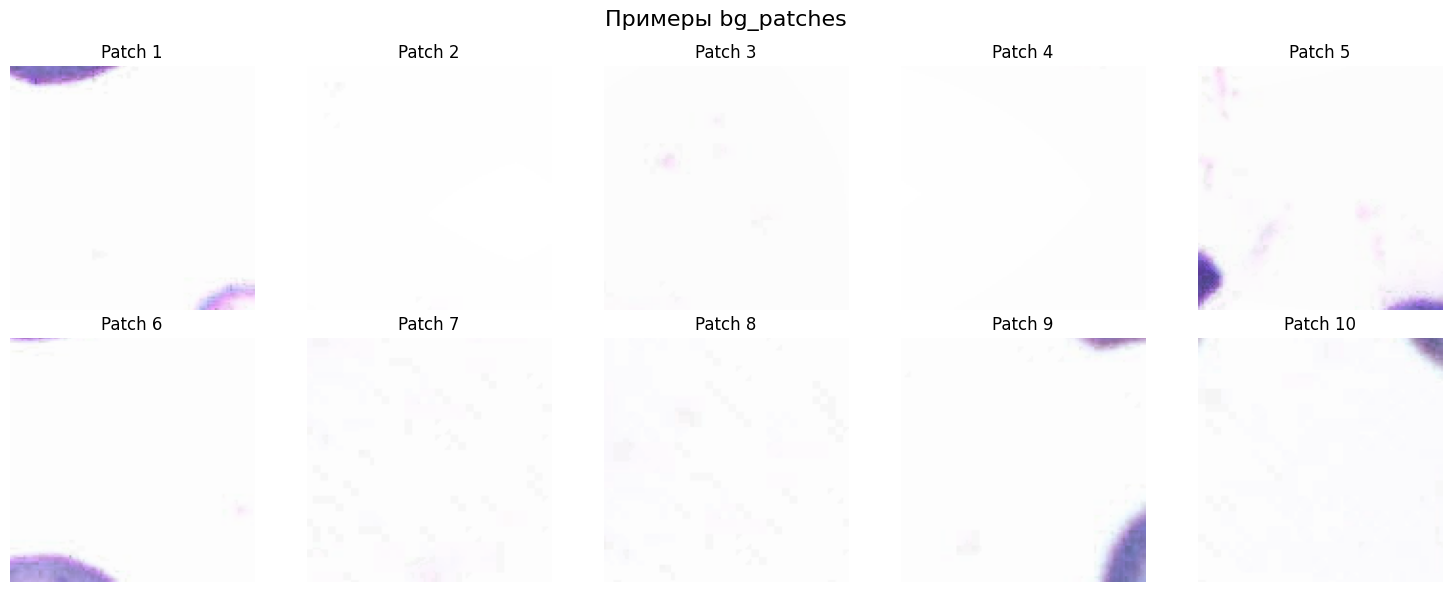

In [26]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle("Примеры bg_patches", fontsize=16)

for i in range(10):
    row = i // 5
    col = i % 5
    axes[row, col].imshow(cv2.cvtColor(bg_patches[i], cv2.COLOR_BGR2RGB))
    axes[row, col].set_title(f"Patch {i+1}")
    axes[row, col].axis('off')

plt.tight_layout()
plt.show()

## 2. Реализация Dataset класса

In [27]:
class CellDetectionDataset(Dataset):
    def __init__(
        self,
        img_size: Tuple[int, int] = (416, 416),
        dataset_size: int = 200,
        bg_patches: List = None,
        cell_patches: List = None,
        p_background_solid: float = 0.3,
        p_cell_artificial: float = 0.3,
        min_cells_count: int = 1,
        max_cells_count: int = 9,
        min_cell_coverage: float = 0.3,
        seed: int = 42
    ):
        random.seed(seed)
        np.random.seed(seed)
        
        self.img_size = img_size
        self.dataset_size = dataset_size
        self.bg_patches = bg_patches if bg_patches else []
        self.cell_patches = cell_patches if cell_patches else []
        self.p_background_solid = p_background_solid
        self.p_cell_artificial = p_cell_artificial
        self.min_cells_count = min_cells_count
        self.max_cells_count = max_cells_count
        self.min_cell_coverage = min_cell_coverage
        
        self.normalize = transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
    
    def __len__(self):
        return self.dataset_size
    
    def __getitem__(self, item):
        target_cells = random.randint(self.min_cells_count, self.max_cells_count)
        clean_img = self._select_background()
        
        cells_img = np.zeros((clean_img.shape[0], clean_img.shape[1], 3), dtype=np.uint8)
        cells_mask = np.zeros((clean_img.shape[0], clean_img.shape[1]), dtype=np.uint8)
        
        bboxes = []
        
        actual_cells_count = 0
        for _ in range(target_cells):
            for _max_attempts in range(2000):
                temp_mask = np.zeros_like(cells_mask)
                temp_img = np.zeros_like(cells_img)
                
                x = random.randint(0, clean_img.shape[1] - 10)
                y = random.randint(0, clean_img.shape[0] - 10)
                
                use_artificial_cell = random.random() < self.p_cell_artificial
                rad = random.randint(12, 25)
                color = self._get_cell_color()
                
                if use_artificial_cell and len(self.cell_patches) > 0:
                    patch = random.choice(self.cell_patches)
                    patch = cv2.resize(patch, (rad*2, rad*2))
                    h_patch, w_patch = patch.shape[:2]
                    x1 = max(0, min(x - w_patch//2, clean_img.shape[1] - w_patch))
                    y1 = max(0, min(y - h_patch//2, clean_img.shape[0] - h_patch))
                    temp_mask[y1:y1+h_patch, x1:x1+w_patch] = 255
                    temp_img[y1:y1+h_patch, x1:x1+w_patch] = patch

                    box_x = x1 + w_patch/2
                    box_y = y1 + h_patch/2
                    box_w = w_patch
                    box_h = h_patch
                elif len(self.cell_patches) > 0:
                    cell_patch = random.choice(self.cell_patches)
                    cell_patch = cv2.resize(cell_patch, (rad*2, rad*2))
                    h_patch, w_patch = cell_patch.shape[:2]
                    x1 = max(0, min(x - w_patch//2, clean_img.shape[1] - w_patch))
                    y1 = max(0, min(y - h_patch//2, clean_img.shape[0] - h_patch))
                    temp_mask[y1:y1+h_patch, x1:x1+w_patch] = 255
                    temp_img[y1:y1+h_patch, x1:x1+w_patch] = cell_patch
                    
                    box_x = x1 + w_patch/2
                    box_y = y1 + h_patch/2
                    box_w = w_patch
                    box_h = h_patch
                else:
                    cv2.circle(temp_mask, center=(x, y), radius=rad, color=255, thickness=-1)
                    cv2.circle(temp_img, center=(x, y), radius=rad, color=color, thickness=-1)
                    box_x = x
                    box_y = y
                    box_w = rad*2
                    box_h = rad*2

                temp_mask_without = cv2.bitwise_and(temp_mask, cv2.bitwise_not(cells_mask))
                coverage = np.count_nonzero(temp_mask_without) / max(1, np.count_nonzero(temp_mask))
                
                if coverage >= self.min_cell_coverage:
                    cells_img = self._add_image_with_mask(cells_img, temp_img, temp_mask_without)
                    cells_mask = self._add_image_with_mask(cells_mask, temp_mask, temp_mask_without)

                    norm_x = box_x / clean_img.shape[1]
                    norm_y = box_y / clean_img.shape[0]
                    norm_w = box_w / clean_img.shape[1]
                    norm_h = box_h / clean_img.shape[0]
                    bboxes.append([norm_x, norm_y, norm_w, norm_h])
                    
                    actual_cells_count += 1
                    break
        
        clean_img = self._add_image_with_mask(clean_img, cells_img, cells_mask)
        image = cv2.cvtColor(clean_img, cv2.COLOR_BGR2RGB)
        image = torch.tensor(image, dtype=torch.float32).permute(2, 0, 1) / 255.0
        image = self.normalize(image)

        return image, torch.tensor(bboxes, dtype=torch.float32), actual_cells_count
    
    def _select_background(self):
        if random.random() < self.p_background_solid or len(self.bg_patches) == 0:
            color = [random.randint(150, 220) for _ in range(3)]
            return np.ones((self.img_size[0], self.img_size[1], 3), dtype=np.uint8) * color
        else:
            bg = np.zeros((self.img_size[0], self.img_size[1], 3), dtype=np.uint8)
            patch_size = 128
            for i in range(0, self.img_size[0], patch_size):
                for j in range(0, self.img_size[1], patch_size):
                    if len(self.bg_patches) > 0:
                        patch = random.choice(self.bg_patches)
                        patch = cv2.resize(patch, (patch_size, patch_size))
                    else:
                        patch = np.ones((patch_size, patch_size, 3), dtype=np.uint8) * 220
                    h_end = min(i + patch_size, self.img_size[0])
                    w_end = min(j + patch_size, self.img_size[1])
                    bg[i:h_end, j:w_end] = patch[:h_end-i, :w_end-j]
            return bg
    
    def _get_cell_color(self):
        return (random.randint(150, 200), random.randint(100, 200), random.randint(50, 150))
    
    def _add_image_with_mask(self, a, b, mask):
        a = a.astype(np.uint8)
        b = b.astype(np.uint8)
        mask = mask.astype(np.uint8)
        result = a.copy()
        result[mask > 0] = b[mask > 0]
        return result

In [28]:
def convert_to_yolo_format(dataset, split_name, output_dir, img_size=(416,416)):
    out_img_dir = os.path.join(output_dir, split_name, 'images')
    out_label_dir = os.path.join(output_dir, split_name, 'labels')
    
    for idx in tqdm(range(len(dataset)), desc=f"Converting {split_name}"):
        img_tensor, bboxes, cell_count = dataset[idx]
        
        img_disp = img_tensor.clone()
        img_disp = img_disp * torch.tensor([0.229, 0.224, 0.225]).view(3,1,1) + torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
        img_disp = (img_disp.permute(1,2,0).numpy() * 255).astype(np.uint8)
        
        img_path = os.path.join(out_img_dir, f"{idx:05d}.png")
        cv2.imwrite(img_path, cv2.cvtColor(img_disp, cv2.COLOR_RGB2BGR))
        
        label_path = os.path.join(out_label_dir, f"{idx:05d}.txt")
        with open(label_path, 'w') as f:
            for box in bboxes:
                f.write(f"0 {box[0]:.6f} {box[1]:.6f} {box[2]:.6f} {box[3]:.6f}\n")

In [29]:
full_dataset = CellDetectionDataset(
    img_size=(416, 416),
    dataset_size=TOTAL_DATA,
    bg_patches=bg_patches,
    cell_patches=cell_patches,
    min_cells_count=1,
    max_cells_count=MAX_CELLS
)

train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

convert_to_yolo_format(train_dataset, 'train', YOLO_DATASET_DIR)
convert_to_yolo_format(val_dataset, 'val', YOLO_DATASET_DIR)

print(f"YOLO датасет создан в {YOLO_DATASET_DIR}")
print(f"Train: {len(train_dataset)} images, Val: {len(val_dataset)} images")

Converting val: 100%|██████████| 200/200 [00:03<00:00, 61.54it/s]

YOLO датасет создан в yolo_cell_dataset
Train: 800 images, Val: 200 images


In [30]:
yaml_content = f"""
path: {os.path.abspath(YOLO_DATASET_DIR)}
train: train/images
val: val/images
nc: 1
names: ['cell']
"""

yaml_path = "cell_dataset.yaml"
with open(yaml_path, 'w') as f:
    f.write(yaml_content)

model = YOLO('yolov8n.pt')

results = model.train(
    data=yaml_path,
    epochs=EPOCHS,
    imgsz=416,
    batch=BATCH_SIZE,
    lr0=LR,
    device='cuda' if torch.cuda.is_available() else 'cpu',
    verbose=True,
    patience=10
)

Ultralytics 8.4.51  Python-3.11.9 torch-2.11.0+cu128 CUDA:0 (NVIDIA GeForce RTX 5060 Ti, 16311MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=cell_dataset.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=416, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-4, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=

In [31]:
def count_cells_from_image(model, image_tensor, confidence_threshold=0.5):
    img_disp = image_tensor.clone()
    img_disp = img_disp * torch.tensor([0.229, 0.224, 0.225]).view(3,1,1) + torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    img_disp = (img_disp.permute(1,2,0).numpy() * 255).astype(np.uint8)
    
    results = model(img_disp, imgsz=416, conf=confidence_threshold)
    detections = results[0].boxes
    if detections is None:
        return 0
    return len(detections)

def relative_error(pred, true):
    return abs(pred - true) / max(true, 1e-6) * 100

model = YOLO('runs/detect/train/weights/best.pt')

test_dataset = val_dataset
predictions = []
ground_truths = []

for i in range(min(100, len(test_dataset))):
    img_tensor, _, true_count = test_dataset[i]
    pred_count = count_cells_from_image(model, img_tensor)
    predictions.append(pred_count)
    ground_truths.append(true_count)
    
    err = relative_error(pred_count, true_count)
    status = "OK" if err < 10 else "FAIL"
    print(f"Image {i+1:3d}: True={true_count:2d}, Pred={pred_count:2d}, Err={err:5.1f}% {status}")

errors = [relative_error(p, t) for p, t in zip(predictions, ground_truths)]
accuracy_within_10_percent = sum(e < 10 for e in errors) / len(errors) * 100

print("\n" + "="*50)
print(f"Средняя относительная погрешность: {np.mean(errors):.2f}%")
print(f"Точность (погрешность <10%): {accuracy_within_10_percent:.2f}%")
print("="*50)


0: 416x416 6 cells, 10.5ms
Speed: 2.2ms preprocess, 10.5ms inference, 3.2ms postprocess per image at shape (1, 3, 416, 416)
Image   1: True= 6, Pred= 6, Err=  0.0% OK

0: 416x416 6 cells, 9.2ms
Speed: 1.5ms preprocess, 9.2ms inference, 1.6ms postprocess per image at shape (1, 3, 416, 416)
Image   2: True= 6, Pred= 6, Err=  0.0% OK

0: 416x416 1 cell, 6.8ms
Speed: 1.6ms preprocess, 6.8ms inference, 4.4ms postprocess per image at shape (1, 3, 416, 416)
Image   3: True= 1, Pred= 1, Err=  0.0% OK

0: 416x416 2 cells, 10.1ms
Speed: 1.3ms preprocess, 10.1ms inference, 2.2ms postprocess per image at shape (1, 3, 416, 416)
Image   4: True= 2, Pred= 2, Err=  0.0% OK

0: 416x416 7 cells, 7.1ms
Speed: 1.7ms preprocess, 7.1ms inference, 1.6ms postprocess per image at shape (1, 3, 416, 416)
Image   5: True= 7, Pred= 7, Err=  0.0% OK

0: 416x416 1 cell, 9.8ms
Speed: 1.5ms preprocess, 9.8ms inference, 1.8ms postprocess per image at shape (1, 3, 416, 416)
Image   6: True= 1, Pred= 1, Err=  0.0% OK

0


0: 416x416 9 cells, 9.3ms
Speed: 4.6ms preprocess, 9.3ms inference, 2.5ms postprocess per image at shape (1, 3, 416, 416)

0: 416x416 9 cells, 9.2ms
Speed: 1.5ms preprocess, 9.2ms inference, 5.4ms postprocess per image at shape (1, 3, 416, 416)

0: 416x416 8 cells, 16.5ms
Speed: 3.9ms preprocess, 16.5ms inference, 9.8ms postprocess per image at shape (1, 3, 416, 416)

0: 416x416 8 cells, 24.0ms
Speed: 1.6ms preprocess, 24.0ms inference, 2.3ms postprocess per image at shape (1, 3, 416, 416)

0: 416x416 4 cells, 8.0ms
Speed: 0.9ms preprocess, 8.0ms inference, 1.5ms postprocess per image at shape (1, 3, 416, 416)

0: 416x416 4 cells, 7.3ms
Speed: 0.8ms preprocess, 7.3ms inference, 1.3ms postprocess per image at shape (1, 3, 416, 416)

0: 416x416 5 cells, 9.0ms
Speed: 0.9ms preprocess, 9.0ms inference, 1.5ms postprocess per image at shape (1, 3, 416, 416)

0: 416x416 5 cells, 9.3ms
Speed: 0.7ms preprocess, 9.3ms inference, 1.7ms postprocess per image at shape (1, 3, 416, 416)

0: 416x416 

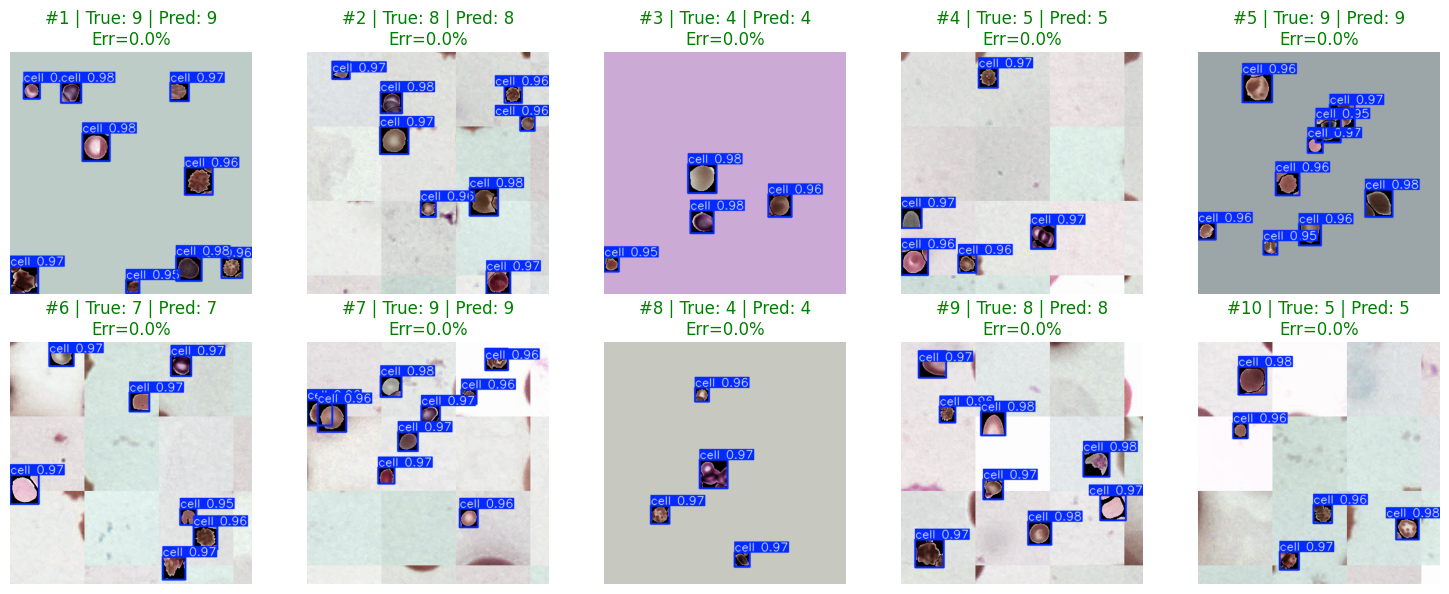

In [38]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i in range(10):
    row, col = i//5, i%5
    img_tensor, _, true_count = test_dataset[i]
    pred_count = count_cells_from_image(model, img_tensor)
    
    img_disp = img_tensor.clone()
    img_disp = img_disp * torch.tensor([0.229, 0.224, 0.225]).view(3,1,1) + torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    img_disp = (img_disp.permute(1,2,0).numpy() * 255).astype(np.uint8)
    
    results = model(img_disp, imgsz=416, conf=0.5)
    annotated = results[0].plot()
    
    axes[row, col].imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
    err = relative_error(pred_count, true_count)
    color = 'green' if err < 10 else 'red'
    axes[row, col].set_title(f"#{i+1} | True: {true_count} | Pred: {pred_count}\nErr={err:.1f}%", color=color)
    axes[row, col].axis('off')

plt.tight_layout()
plt.show()


0: 416x416 4 cells, 8.8ms
Speed: 1.1ms preprocess, 8.8ms inference, 1.6ms postprocess per image at shape (1, 3, 416, 416)

0: 416x416 4 cells, 8.8ms
Speed: 0.9ms preprocess, 8.8ms inference, 1.8ms postprocess per image at shape (1, 3, 416, 416)


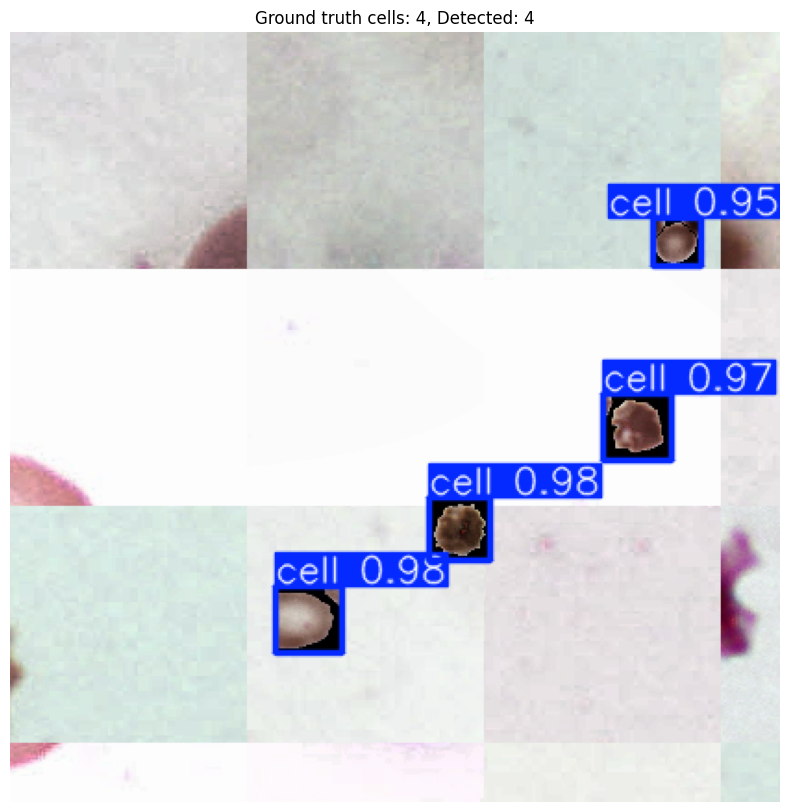

Относительная погрешность: 0.00%


In [41]:
sample_idx = 5
img_tensor, bboxes, true_count = test_dataset[sample_idx]
pred_count = count_cells_from_image(model, img_tensor)

img_disp = img_tensor.clone()
img_disp = img_disp * torch.tensor([0.229, 0.224, 0.225]).view(3,1,1) + torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
img_disp = (img_disp.permute(1,2,0).numpy() * 255).astype(np.uint8)

results = model(img_disp, imgsz=416, conf=0.5)
annotated = results[0].plot()

plt.figure(figsize=(10,10))
plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
plt.title(f"Ground truth cells: {true_count}, Detected: {pred_count}")
plt.axis('off')
plt.show()

print(f"Относительная погрешность: {relative_error(pred_count, true_count):.2f}%")